# Reducing US Traffic Accidents

## Overview
This notebook is an analysis of US Traffic Accidents from 2018-2023.

BLUF

Pre-lim Analysis questions
1. Where — which geographic areas have disproportionately high severity 3/4 accidents relative to total accidents? (infrastructure investment)
2. When — what time patterns correlate with severity 3/4 accidents? (targeted enforcement, campaigns)
3. What conditions — which weather or road feature combinations are most associated with severity 3/4 accidents? (safety treatments, standards)

## Business Understanding
Define the problem clearly and identify key questions that your analysis should answer. Determine how success will be measured and what insights would be valuable to stakeholders.

*Context:* The Federal Department of Transportation (DoT) mission is to ensure the nation has the safest, most efficient, and modern transportation system. Traffic accidents directly undermine this goal by reducing safety, disrupting commerce, and straining emergency response systems.

*Business Impact—The Cost of Accidents:*

The economic and human toll of traffic accidents is staggering. According to DoT and NHTSA data, crashes cost the U.S. economy billions annually through medical expenses, property damage, lost productivity, and lost quality of life. The comprehensive costs per accident vary dramatically by severity:[1, 2, 6]

- Severity 4 accidents (suspected serious injury) cost approximately $1,112,900 per crash
- Severity 3 accidents (minor/evident injury) cost approximately $354,100 per crash
- Severity 2 accidents (possible injury) cost approximately $208,000 per crash

Beyond direct costs, severity 3/4 accidents typically block roadways for 1-3+ hours, contributing to the $36 billion annual cost of congestion-related losses.[12] Given that severity 3/4 accidents represent only 19% of all crashes in this dataset but generate disproportionate costs, targeting these high-impact incidents offers the greatest return on safety investment.

*Problem Statement:* Not all accidents have equal impact. While severity 2 accidents are high-volume (80% of incidents), severity 3/4 accidents drive the majority of economic loss and operational disruption. Understanding *which geographic areas, times, and conditions* produce the most severe accidents enables DoT to allocate limited resources strategically.

*Business Objectives:*
1. **Reduce severity 3/4 accident frequency** in high-risk geographic areas through targeted infrastructure investment
2. **Mitigate temporal peaks** (weekends, early morning, winter months) with enforcement and awareness campaigns
3. **Address weather-specific risks** (snow, rain interactions) with condition-adaptive safety treatments
4. **Optimize resource allocation** (emergency response, traffic management) based on predictive severity patterns

*Expected Impact:* By targeting interventions to high-severity times, places, and conditions, DoT can reduce response times, minimize traffic disruption, prevent injuries, and lower incident-related healthcare and economic costs.

*References:*
[1] Mass.gov. (2024). Crash Costs for Highway Safety Analysis. https://www.mass.gov/info-details/crash-costs-for-highway-safety-analysis
[2] National Safety Council. (2023). Guide to Calculating Costs. https://injuryfacts.nsc.org/all-injuries/costs/guide-to-calculating-costs/data-details/
[6] Federal Motor Carrier Safety Administration. (2024). Crash Cost Methodology Report. https://www.fmcsa.dot.gov
[12] NHTSA. (2019). Traffic Crashes Cost America Billions. https://www.nhtsa.gov/press-releases/traffic-crashes-cost-america-billions-2019

## Data Understanding
Exploring the US Accidents dataset to understand its structure, variables, scope, and limitations.

Identifying potential issues with the data and assess its suitability for addressing the business problem.

In [58]:
# load in required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px

from scipy.stats import chi2_contingency
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

Since the dataset is too big for github, download the file from Kaggle, unzip and put file in data directory.
Dataset from [Kaggle](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data) and place into `data/`
Run cell below to convert .csv into .parquet file for faster loading

In [2]:
# read csv file and convert to .parquet for faster loading
# data_csv = pd.read_csv('data/US_Accidents_March23.csv')
# data_csv.write_parquet('data/US_Accidents_March23.parquet')

In [3]:
df = pd.read_parquet('data/US_Accidents_March23.parquet')
# copy data to keep raw and cleaned separate
clean_df = df.copy()

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

### Columns Description
* ID: This is a unique identifier of the accident record.
* Source: Source of raw accident data
* Severity: Shows the severity of the accident, a number between 1 and 4, where 1 indicates the least impact on traffic (i.e., short delay as a result of the accident) and 4 indicates a significant impact on traffic (i.e., long delay).
* Start_Time: Shows start time of the accident in local time zone.
* End_Time: Shows end time of the accident in local time zone. End time here refers to when the impact of accident on traffic flow was dismissed.
* Start_Lat: Shows latitude in GPS coordinate of the start point.
* Start_Lng: Shows longitude in GPS coordinate of the start point.
* End_Lat: Shows latitude in GPS coordinate of the end point.
* End_Lng: Shows longitude in GPS coordinate of the end point.
* Distance(mi): The length of the road extent affected by the accident in miles.
* Description: Shows a human provided description of the accident.
* Street: Shows the street name in address field.
* City: Shows the city in address field.
* County: Shows the county in address field.
* State: Shows the state in address field.
* Zipcode: Shows the zipcode in address field.
* Country: Shows the country in address field.
* Timezone: Shows timezone based on the location of the accident (eastern, central, etc.).
* Airport_Code: Denotes an airport-based weather station which is the closest one to location of the accident.
* Weather_Timestamp: Shows the time-stamp of weather observation record (in local time).
* Temperature(F): Shows the temperature (in Fahrenheit).
* Wind_Chill(F): Shows the wind chill (in Fahrenheit).
* Humidity(%): Shows the humidity (in percentage).
* Pressure(in): Shows the air pressure (in inches).
* Visibility(mi): Shows visibility (in miles).
* Wind_Direction: Shows wind direction.
* Wind_Speed(mph): Shows wind speed (in miles per hour).
* Precipitation(in): Shows precipitation amount in inches, if there is any.
* Weather_Condition: Shows the weather condition (rain, snow, thunderstorm, fog, etc.)
* Amenity: A POI annotation which indicates presence of amenity in a nearby location.
* Bump: A POI annotation which indicates presence of speed bump or hump in a nearby location.
* Crossing: A POI annotation which indicates presence of crossing in a nearby location.
* Give_Way: A POI annotation which indicates presence of give_way in a nearby location.
* Junction: A POI annotation which indicates presence of junction in a nearby location.
* No_Exit: A POI annotation which indicates presence of no_exit in a nearby location.
* Railway: A POI annotation which indicates presence of railway in a nearby location.
* Roundabout: A POI annotation which indicates presence of roundabout in a nearby location.
* Station: A POI annotation which indicates presence of station in a nearby location.
* Stop: A POI annotation which indicates presence of stop in a nearby location.
* Traffic_Calming: A POI annotation which indicates presence of traffic_calming in a nearby location.
* Traffic_Signal: A POI annotation which indicates presence of traffic_signal in a nearby location.
* Turning_Loop: A POI annotation which indicates presence of turning_loop in a nearby location.
* Sunrise_Sunset: Shows the period of day (i.e. day or night) based on sunrise/sunset.
* Civil_Twilight: Shows the period of day (i.e. day or night) based on civil twilight.
* Nautical_Twilight: Shows the period of day (i.e. day or night) based on nautical twilight.
* Astronomical_Twilight: Shows the period of day (i.e. day or night) based on astronomical twilight.

In [5]:
# verbose setting for .head()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


# Data Preparation
Clean and preprocess the data, handling missing values, outliers, and duplicates. Create derived features that might provide additional insights (e.g., time of day categories, weather condition groupings).

In [7]:
# show missing values as percent of dataset, sorted from highest to lowest
missing = (
    (clean_df.isna().sum() / len(clean_df))
        .mul(100)
        .sort_values(ascending=False)
        .loc[lambda pct_missing: pct_missing > 0]
        .rename("missing_%")
        .to_frame()
)
missing

,missing_%
End_Lat,44.029355
End_Lng,44.029355
Precipitation(in),28.512858
Wind_Chill(F),25.865904
Wind_Speed(mph),7.391355
Visibility(mi),2.291524
Wind_Direction,2.267043
Humidity(%),2.253301
Weather_Condition,2.244438
Temperature(F),2.120143


## Cleaning Strategy

**Geospatial**
* `End_Lat` / `End_Lng` (~50% missing): Dropped. Start coordinates combined with distance provide sufficient spatial context if needed.
* `Airport_Code`, `Street`, `Timezone` (small % missing): Rows dropped — imputation is impractical for these identifiers.
* `City`, `Zipcode`: Retained for high-accident-volume analysis.

**Weather Sensors**
* `Precipitation` (~28% missing): Rather than imputing — which would introduce artificial values where none likely existed — nulls are preserved and a binary flag `Precipitation_Recorded` is added to distinguish "no data" from "no precipitation."
* `Wind_Chill(F)` (~26% missing): A binary flag `Wind_Chill_Present` is added to indicate when wind chill is applicable (temp < 50°F and wind speed > 3 mph). Missing values are then imputed using the NOAA wind chill formula rather than a simple median, since wind chill is calculable from existing variables.
* `Wind_Speed` (~7% missing): Imputed with the **median**. Absence of wind is unlikely; sensor malfunction is the more plausible explanation.
* `Wind_Direction` (low % missing): Imputed with **state-grouped mode** (categorical).
* `Visibility(mi)`, `Humidity(%)`, `Pressure(in)`, `Temperature(F)` (low % missing): Imputed with **state-grouped median**. These are supporting variables with minimal missingness.

**Weather Condition**
* `Weather_Condition` (primary variable): Imputed with **state-grouped mode**. Being categorical, mode is appropriate; state grouping adds geographic specificity.

**Temporal / Lighting**
* `Sunrise_Sunset`, `Nautical_Twilight`, `Astronomical_Twilight`: Dropped — low analytical value.
* `Civil_Twilight`: Retained as a potentially insightful lighting indicator. The ~0.3% missing rows are dropped.

In [8]:
# dropping End_lat and End_Lng since it is missing around 50% of values
# drop `Airport_Code`, `Street`, `Timezone`
clean_df = clean_df.drop(columns = ['End_Lat', 'End_Lng','Airport_Code','Street','Timezone','Sunrise_Sunset', 'Nautical_Twilight', 'Astronomical_Twilight'])

In [9]:
# create flag for whether precipitation is recorded
clean_df['Precipitation_Recorded'] = clean_df['Precipitation(in)'].notna().astype(bool)

In [10]:
# create a boolean mask for rows where wind chill should be present (temp < 50F and wind speed > 3mph)
# but is missing. Use the mask to calculate and fill wind chill values using the NOAA formula, only for the relevant rows

# col for where wind chill should have been calculated
clean_df['Wind_Chill_Present'] = (clean_df['Wind_Speed(mph)'] > 3) & (clean_df['Temperature(F)'] < 50)

mask = clean_df['Wind_Chill(F)'].isna() & clean_df['Wind_Chill_Present']

clean_df.loc[mask, 'Wind_Chill(F)'] = (
    35.75 
    + 0.6215 * clean_df.loc[mask, 'Temperature(F)'] 
    - 35.75 * clean_df.loc[mask, 'Wind_Speed(mph)'] ** 0.16 
    + 0.4275 * clean_df.loc[mask, 'Temperature(F)'] ** 0.16
)

In [11]:
# handle missing values for wind speed, visiblity, humidity, pressure, temperature - impute median by state
# .transform here so that it matches the df shape
clean_df['Wind_Speed(mph)'] = clean_df.groupby('State')['Wind_Speed(mph)'].transform(lambda state_vals: state_vals.fillna(state_vals.median()))
clean_df['Visibility(mi)'] = clean_df.groupby('State')['Visibility(mi)'].transform(lambda state_vals: state_vals.fillna(state_vals.median()))
clean_df['Humidity(%)'] = clean_df.groupby('State')['Humidity(%)'].transform(lambda state_vals: state_vals.fillna(state_vals.median()))
clean_df['Pressure(in)'] = clean_df.groupby('State')['Pressure(in)'].transform(lambda state_vals: state_vals.fillna(state_vals.median()))
clean_df['Temperature(F)'] = clean_df.groupby('State')['Temperature(F)'].transform(lambda state_vals: state_vals.fillna(state_vals.median()))

# handle missing values for wind direction, weather condition impute mode for categorical
clean_df['Wind_Direction'] = clean_df.groupby('State')['Wind_Direction'].transform(lambda state_vals: state_vals.fillna(state_vals.mode()[0]))


In [12]:
# missing row drops
clean_df=clean_df.dropna(subset=['Civil_Twilight','Zipcode','City'],axis=0)

### Value Standardization and Type Casting

Wind Direction
CALM > Calm
South > S
North > N
East > E
West > W
Variable > VAR

Weather Condition
Create categories to group similar weather conditions and also create a binary flag `is_windy` for any windy suffix
| Category | Examples |
|---|---|
| **Clear / Fair** | Fair, Clear |
| **Cloudy** | Mostly Cloudy, Partly Cloudy, Overcast, Scattered Clouds |
| **Fog / Mist** | Fog, Mist, Haze, Shallow Fog, Patches of Fog, Partial Fog |
| **Rain** | Light Rain, Rain, Heavy Rain, Drizzle, Light Drizzle, Heavy Drizzle, Freezing Rain |
| **Snow** | Light Snow, Snow, Heavy Snow, Snow Grains, Blowing Snow, Drifting Snow |
| **Winter Mix** | Wintry Mix, Snow and Sleet, Light Snow and Sleet, Sleet, Ice Pellets, Light Freezing Drizzle |
| **Thunderstorm** | Thunder, T-Storm, Thunderstorm, Heavy T-Storm, Light Rain with Thunder |
| **Severe / Hazardous** | Tornado, Funnel Cloud, Squalls, Hail, Small Hail, Duststorm |
| **Atmospheric** | Smoke, Sand, Blowing Dust, Widespread Dust, Volcanic Ash |


In [13]:
# check for variations in wind directions and wind conditions
print(clean_df['Wind_Direction'].value_counts())
print(clean_df['Weather_Condition'].value_counts())

Wind_Direction
CALM        1091373
S            420194
WNW          388035
SSW          385844
W            382519
NW           369201
Calm         368649
SW           363440
SSE          357954
WSW          354011
NNW          332405
N            305792
SE           294141
E            289292
ESE          267534
NE           257764
ENE          257715
NNE          254475
VAR          249815
South        177366
West         164747
North        153481
Variable     113994
East         103533
Name: count, dtype: int64
Weather_Condition
Fair                                   2550862
Mostly Cloudy                          1014209
Cloudy                                  814076
Clear                                   808714
Partly Cloudy                           697371
Overcast                                382856
Light Rain                              351979
Scattered Clouds                        204820
Light Snow                              128092
Fog                                   

In [14]:
# standardize wind directions
wind_direction_map = {'Calm':'CALM',
         'East':'E',
         'North':'N',
         'South':'S',
         'West':'W',
         'Variable':'VAR',
        }
clean_df['Wind_Direction'] = clean_df['Wind_Direction'].replace(wind_direction_map)
clean_df['Wind_Direction'].value_counts()

Wind_Direction
CALM    1460022
S        597560
W        547266
N        459273
E        392825
WNW      388035
SSW      385844
NW       369201
VAR      363809
SW       363440
SSE      357954
WSW      354011
NNW      332405
SE       294141
ESE      267534
NE       257764
ENE      257715
NNE      254475
Name: count, dtype: int64

In [15]:
# binary flag for windy and strip from weather_condition
clean_df['Is_Windy'] = clean_df['Weather_Condition'].str.lower().str.contains('windy',regex=False, na=False)
clean_df['Weather_Condition'] = clean_df['Weather_Condition'].str.replace(r'\s*/\s*Windy', '', regex=True)


In [16]:
# One-hot encode for different conditions
clean_df['Clear_Fair'] = clean_df['Weather_Condition'].str.contains('fair|clear', case = False).astype(bool)
clean_df['Cloudy'] = clean_df['Weather_Condition'].str.contains('cloudy|mostly cloudy|partly cloudy|overcast|scattered clouds', case = False, na=False).astype(bool)
clean_df['Fog_Mist'] = clean_df['Weather_Condition'].str.contains('fog|mist|haze|shallow fog|patches of fog|partial fog', case = False, na=False).astype(bool)
clean_df['Rain'] = clean_df['Weather_Condition'].str.contains('rain|light rain|heavy rain|drizzle|light drizzle|heavy drizzle|freezing rain', case = False, na=False).astype(bool)
clean_df['Snow'] = clean_df['Weather_Condition'].str.contains('snow|light snow|heavy snow|snow grains|blowing snow|drifting snow', case = False, na=False).astype(bool)
clean_df['Winter Mix'] = clean_df['Weather_Condition'].str.contains('wintry mix|snow and sleet|light snow and sleet|sleet|ice pellets|light freezing drizzle', case = False, na=False).astype(bool)
clean_df['Thunderstorm'] = clean_df['Weather_Condition'].str.contains('thunder|storm|t-storm|thunderstorm|heavy t-storm|light rain with thunder', case = False, na=False).astype(bool)
clean_df['Severe_Hazardous'] = clean_df['Weather_Condition'].str.contains('tornado|funnel cloud|squalls|hail|small hail|duststorm', case = False, na=False).astype(bool)
clean_df['Atmospheric Obscurations'] = clean_df['Weather_Condition'].str.contains('smoke|sand|blowing dust|widespread dust|volcanic ash', case = False, na=False).astype(bool)

In [17]:
# If Weather_Condition == "N/A Precipitation" → Precipitation_Recorded = 0
# Then reclassify those rows' Weather_Condition into whatever the base condition actually is (likely Clear / Fair or Cloudy given the context)
# That way N/A Precipitation doesn't survive as its own weather category, and the precipitation signal is consistently handled by your flag.
mask = clean_df['Weather_Condition'] == 'N/A Precipitation'
clean_df.loc[mask & (clean_df['Precipitation(in)'] > 0), 'Precipitation_Recorded'] = True
clean_df.loc[mask & (clean_df['Precipitation(in)'].isna() | (clean_df['Precipitation(in)'] == 0)), 'Precipitation_Recorded'] = False

In [18]:
# Start_Time, End_Time, Weather_Timestamp should be datetime for time-based analysis

clean_df['Start_Time'] =pd.to_datetime(clean_df['Start_Time'], format='mixed')
clean_df['End_Time'] =pd.to_datetime(clean_df['End_Time'], format='mixed')
clean_df['Weather_Timestamp']=pd.to_datetime(clean_df['Weather_Timestamp'], format='mixed')

# change to category dtype to save memory and speed up on groupby. good for 7M+ rows

cat_cols = ['State', 'Country', 'Wind_Direction', 
            'Weather_Condition', 'Civil_Twilight']
clean_df[cat_cols] = clean_df[cat_cols].astype('category')

In [19]:
clean_df[clean_df['Weather_Condition'] == 'N/A Precipitation']['Precipitation(in)'].value_counts(dropna=False)

Precipitation(in)
0.00    2552
0.01     223
0.02     118
0.03      63
0.05      52
NaN       33
0.06      32
0.04      31
0.14      25
0.10      23
0.08      20
0.09       9
0.11       8
0.16       6
0.07       6
0.28       4
0.20       3
0.15       3
0.21       2
0.17       2
0.12       2
0.23       1
0.26       1
0.18       1
0.22       1
0.27       1
0.24       1
0.19       1
0.29       1
Name: count, dtype: int64

In [20]:
# check clean_Df
print(clean_df.info())
print(clean_df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 7703274 entries, 0 to 7728393
Data columns (total 50 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   ID                        object        
 1   Source                    object        
 2   Severity                  int64         
 3   Start_Time                datetime64[ns]
 4   End_Time                  datetime64[ns]
 5   Start_Lat                 float64       
 6   Start_Lng                 float64       
 7   Distance(mi)              float64       
 8   Description               object        
 9   City                      object        
 10  County                    object        
 11  State                     category      
 12  Zipcode                   object        
 13  Country                   category      
 14  Weather_Timestamp         datetime64[ns]
 15  Temperature(F)            float64       
 16  Wind_Chill(F)             float64       
 17  Humidity(%)  

In [21]:
# hard bound outliers for humidity (>100 and <0), neg values for wind-speed, 
# temperature >134 and <-80, wind speed, outliers
# lowest wind-chill -103
# http://en.wikipedia.org/wiki/U.S._state_and_territory_temperature_extremes
# https://mountwashington.org/remembering-the-big-wind/
# https://en.wikipedia.org/wiki/Atmospheric_pressure#:~:text=The%20highest%20adjusted%2Dto%2Dsea,1%2C083.8%20hPa%20(32.005%20inHg).
# 
print('Num Humidity out of bound:',len(clean_df[ (clean_df['Humidity(%)'] > 100) | (clean_df['Humidity(%)'] <0)]))
print('Num Wind Speed out of bound:',len(clean_df[ (clean_df['Wind_Speed(mph)']<0) | (clean_df['Wind_Speed(mph)']>231)]))
print('Num Temperature out of bound:',len(clean_df[ (clean_df['Temperature(F)'] > 134) | (clean_df['Temperature(F)'] <-80)]))
print('Num Pressure out of bound:',len(clean_df[ (clean_df['Pressure(in)']<20) | (clean_df['Pressure(in)']>40)]))

Num Humidity out of bound: 0
Num Wind Speed out of bound: 26
Num Temperature out of bound: 52
Num Pressure out of bound: 390


In [22]:
mask = ((clean_df['Wind_Speed(mph)']<0) | (clean_df['Wind_Speed(mph)']>231)) | \
((clean_df['Temperature(F)'] > 134) | (clean_df['Temperature(F)'] <-80))| \
((clean_df['Pressure(in)']<20) | (clean_df['Pressure(in)']>40) )

clean_df = clean_df[~mask]

In [23]:
for attr in ['year', 'month', 'day', 'hour', 'weekday', 'day_name']:
    value = getattr(clean_df['Start_Time'].dt, attr)
    # Check if the attribute is a method (like day_name) and call it
    clean_df[f'Start_{attr.capitalize()}'] = value() if callable(value) else value

In [24]:
# Total accidents by severity level (counts and percentages)
# Date range of the dataset
# Geographic coverage (how many states, cities)
# Summary stats for key numerical columns
print('Total Accidents by severity', clean_df['Severity'].value_counts())
print(f"Accidents from: {clean_df['Start_Time'].min()} to: {clean_df['Start_Time'].max()}")
print(f"{clean_df['State'].nunique()} states and {clean_df['City'].nunique()} cities represented.")

print('='*50)
# geographic stats
state_severity = clean_df.groupby('State')['Severity'].value_counts(normalize=True)

print("\nTop 10 States for Severity 2:")
print(state_severity.xs(key=2, level='Severity').sort_values(ascending=False).head(10))
print("Top 10 States for Severity 3:")
print(state_severity.xs(key=3, level='Severity').sort_values(ascending=False).head(10))
print("\nTop 10 States for Severity 4:")
print(state_severity.xs(key=4, level='Severity').sort_values(ascending=False).head(10))

print('='*50)
# Temporal stats
day_name_severity = clean_df.groupby('Start_Day_name')['Severity'].value_counts(normalize=True)
print("\n day_name proportion severity 2:")
print(day_name_severity.xs(key=2, level='Severity'))
print("\n day_name proportion severity 3:")
print(day_name_severity.xs(key=3, level='Severity'))
print("\n day_name proportion severity 4:")
print(day_name_severity.xs(key=4, level='Severity'))

print(clean_df['Start_Year'].value_counts())

Total Accidents by severity Severity
2    6135095
3    1298264
4     202300
1      67147
Name: count, dtype: int64
Accidents from: 2016-01-14 20:18:33 to: 2023-03-31 23:30:00
49 states and 12445 cities represented.


/var/folders/p8/_r92c00j59v3wz7mp8x9d9740000gn/T/ipykernel_86686/949124240.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_severity = clean_df.groupby('State')['Severity'].value_counts(normalize=True)



Top 10 States for Severity 2:
State
ND    0.989637
MT    0.978784
ID    0.932435
OR    0.905604
WV    0.900753
OK    0.897331
DC    0.884694
NC    0.866679
SC    0.864547
FL    0.858556
Name: proportion, dtype: float64
Top 10 States for Severity 3:
State
RI    0.455365
KY    0.388655
GA    0.362260
IL    0.342243
MO    0.338214
MA    0.300410
CO    0.290795
WI    0.278030
NM    0.277659
WA    0.276731
Name: proportion, dtype: float64

Top 10 States for Severity 4:
State
SD    0.189076
WY    0.143519
AR    0.117786
DE    0.109641
WI    0.098949
VT    0.095445
IN    0.082257
CO    0.082210
MD    0.077389
IA    0.076855
Name: proportion, dtype: float64

 day_name proportion severity 2:
Start_Day_name
Friday       0.799585
Monday       0.797307
Saturday     0.786158
Sunday       0.772248
Thursday     0.799912
Tuesday      0.800024
Wednesday    0.801153
Name: proportion, dtype: float64

 day_name proportion severity 3:
Start_Day_name
Friday       0.167584
Monday       0.167699
Saturday    

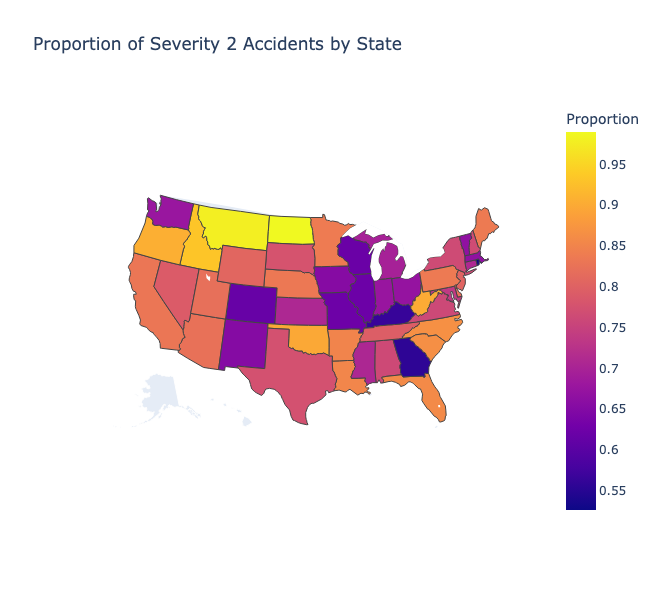

In [25]:
sev2 = state_severity.xs(key=2, level='Severity').reset_index()
sev2.columns = ['State', 'Proportion']

fig = px.choropleth(
    sev2,
    locations='State',
    locationmode='USA-states',
    color='Proportion',
    scope='usa',
    title='Proportion of Severity 2 Accidents by State'
)
fig.update_layout(width=800, height=600)
fig.show()

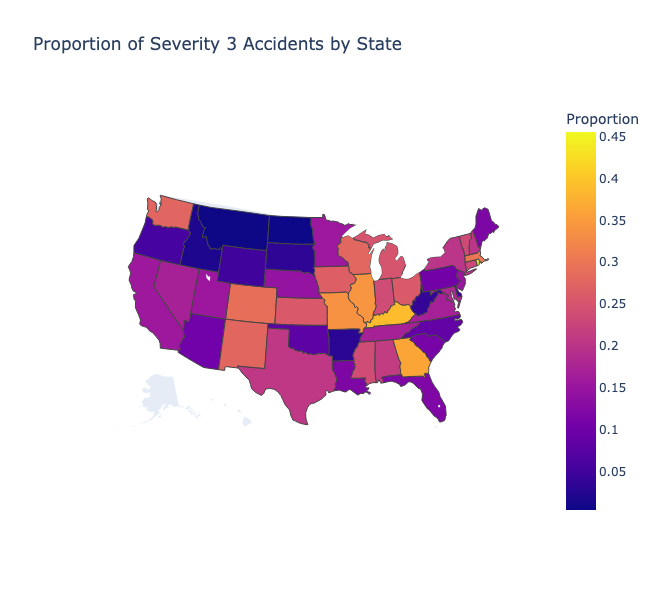

In [26]:
sev3 = state_severity.xs(key=3, level='Severity').reset_index()
sev3.columns = ['State', 'Proportion']

fig = px.choropleth(
    sev3,
    locations='State',
    locationmode='USA-states',
    color='Proportion',
    scope='usa',
    title='Proportion of Severity 3 Accidents by State'
)
fig.update_layout(width=800, height=600)
fig.show()

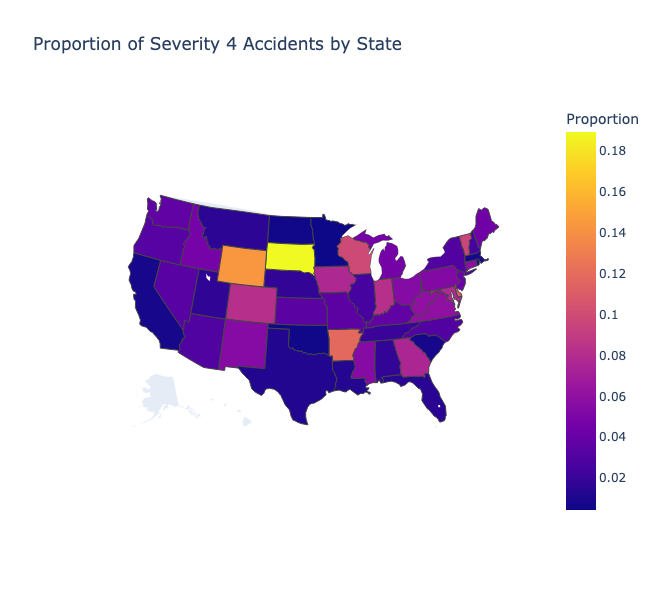

In [27]:
sev4 = state_severity.xs(key=4, level='Severity').reset_index()
sev4.columns = ['State', 'Proportion']

fig = px.choropleth(
    sev4,
    locations='State',
    locationmode='USA-states',
    color='Proportion',
    scope='usa',
    title='Proportion of Severity 4 Accidents by State'
)

fig.update_layout(width=800, height=600)
fig.show()

# Geospatial findings
severity

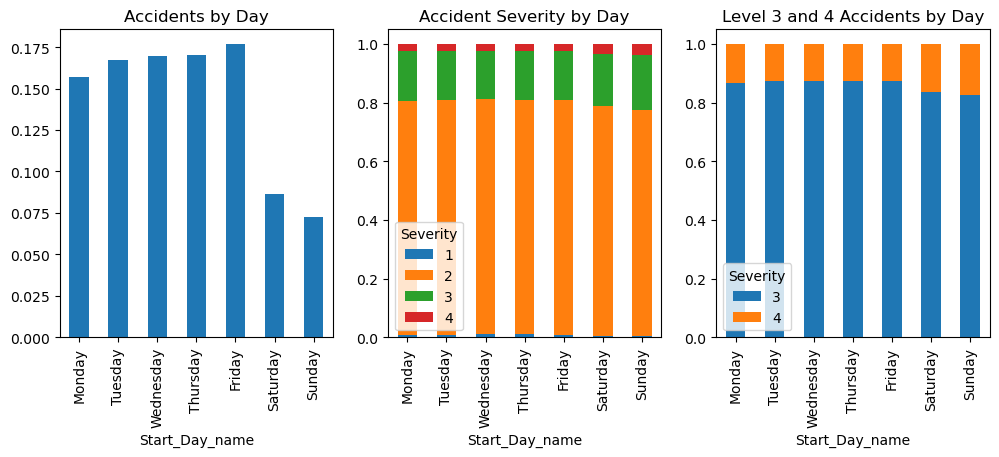

In [28]:
# temporal viz - nationwide
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# spread of when accidents occur
day_df = clean_df['Start_Day_name'].value_counts(normalize=True)
day_df = day_df.reindex(day_order)
day_df.plot(kind='bar',ax=axes[0],title='Accidents by Day')

# spread of sev by day of week
sev_day = clean_df.groupby('Start_Day_name')['Severity'].value_counts().unstack()
norm_sev_day = sev_day.div(sev_day.sum(axis=1), axis=0)
norm_sev_day=norm_sev_day.reindex(day_order)
norm_sev_day.plot(kind='bar',ax=axes[1],stacked=True, title='Accident Severity by Day')

# focus on 3 & 4 sev
sev_34_df = clean_df[clean_df['Severity'].isin([3, 4])]
sev_day = sev_34_df.groupby('Start_Day_name')['Severity'].value_counts().unstack()
norm_sev_34 = sev_day.div(sev_day.sum(axis=1), axis=0)
norm_sev_34=norm_sev_34.reindex(day_order)
norm_sev_34.plot(kind='bar',ax=axes[2],stacked=True, title='Level 3 and 4 Accidents by Day')
plt.show()

<Figure size 2000x600 with 0 Axes>

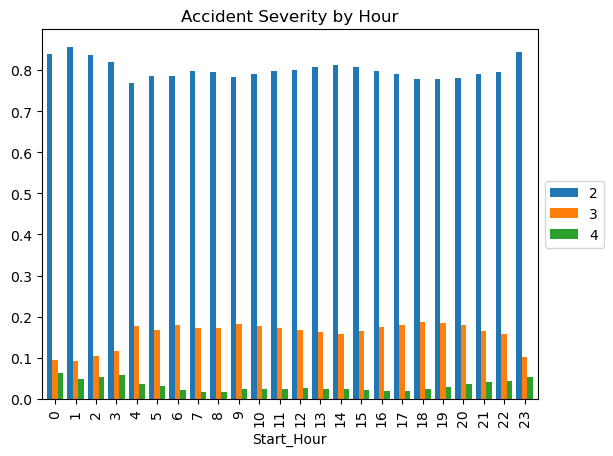

In [29]:
# hourly
fig = plt.figure(figsize=(20, 6))

sev_hour = clean_df.groupby('Start_Hour')['Severity'].value_counts().unstack()
norm_hour = sev_hour.div(sev_hour.sum(axis=1), axis=0)
norm_hour[[2,3,4]].plot(kind='bar',width=0.8,title='Accident Severity by Hour').legend(loc='center left',bbox_to_anchor=(1.0, 0.5))

plt.show()

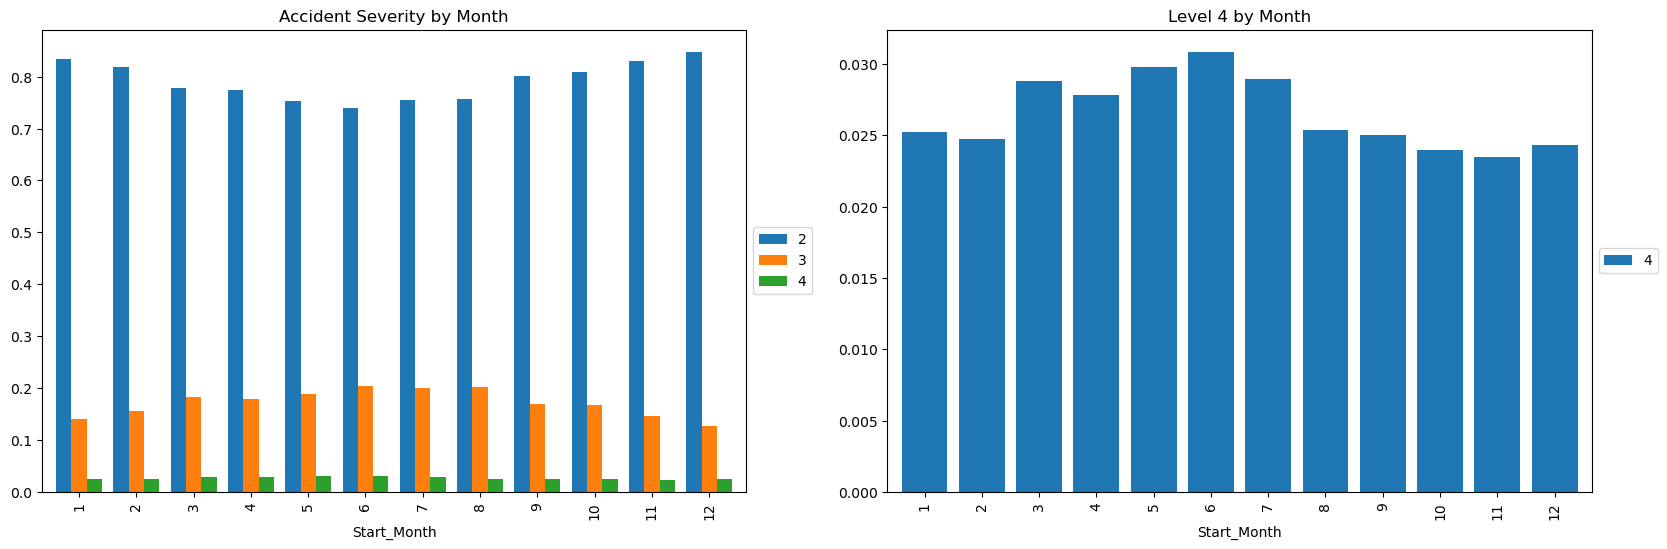

In [30]:
# monthly
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sev_month = clean_df.groupby('Start_Month')['Severity'].value_counts().unstack()
norm_month= sev_month.div(sev_month.sum(axis=1), axis=0)
norm_month[[2,3,4]].plot(kind='bar',ax=axes[0],width=0.8,title='Accident Severity by Month').legend(loc='center left',bbox_to_anchor=(1.0, 0.5))

norm_month[4].plot(kind='bar',ax=axes[1],width=0.8,title='Level 4 by Month').legend(loc='center left',bbox_to_anchor=(1.0, 0.5))

plt.show()

# Temporal Findings

<Axes: xlabel='Severity'>

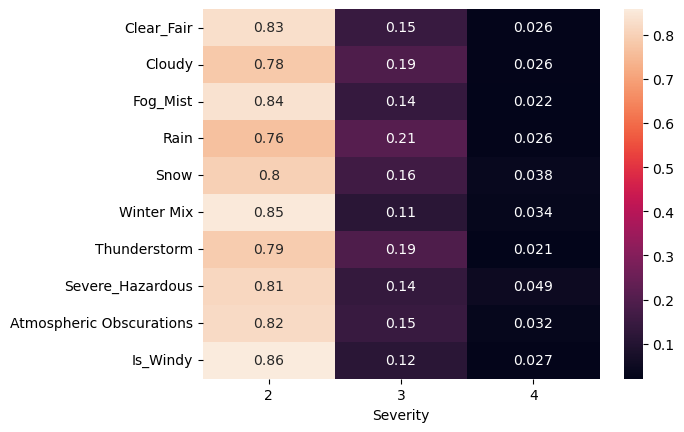

In [33]:
# weather factors
condition_cols = ['Clear_Fair', 'Cloudy', 'Fog_Mist', 'Rain', 'Snow', 'Winter Mix', 'Thunderstorm', 'Severe_Hazardous', 'Atmospheric Obscurations', 'Is_Windy']
sev_234_df = clean_df[clean_df['Severity'].isin([2,3,4])]
condition_data = sev_234_df[['Severity']+condition_cols]
grouped_234 = sev_234_df[['Severity'] + condition_cols].groupby('Severity')[condition_cols].sum()
normalized_sev = grouped_234.div(grouped_234.sum(axis=0), axis=1)

sns.heatmap(normalized_sev.transpose(), annot=True)

Exactly. Clear/Fair dominates the dataset, so it accounts for many severity 4 accidents by sheer volume, not because clear weather causes severity 4.
But here's the actionable insight: Severe/Hazardous and Snow/Winter Mix conditions have disproportionately high severity 4 rates. That's what your DoT audience should care about—conditions that reliably produce severe accidents, not just which conditions accidents happen in.

<Axes: title={'center': 'Snow and Low Visibility (<1 mi)'}, xlabel='Snow_and_LowViz'>

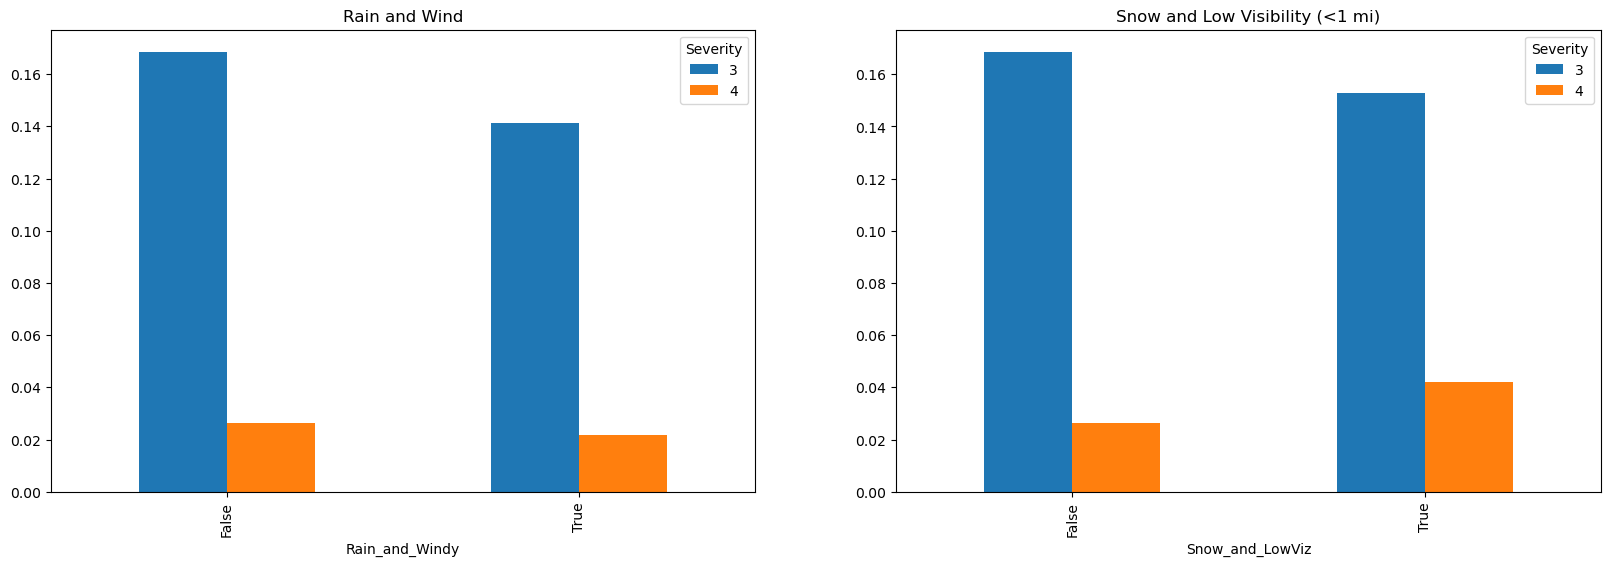

In [34]:
# Rain + Wind Interaction
clean_df['Rain_and_Windy'] = (clean_df['Precipitation(in)']>0) & (clean_df['Is_Windy']==1)
rain_wind = clean_df.groupby('Rain_and_Windy')['Severity'].value_counts().unstack()
norm_rain_wind = rain_wind.div(rain_wind.sum(axis=1),axis=0)

# Snow + Low Visibility Interaction
clean_df['Low_Visibility(mi)'] = clean_df['Visibility(mi)']<1
clean_df['Snow_and_LowViz'] = (clean_df['Snow']==1) & (clean_df['Low_Visibility(mi)']==1)
snow_lowviz = clean_df.groupby('Snow_and_LowViz')['Severity'].value_counts().unstack()
norm_snow_lowviz = snow_lowviz.div(snow_lowviz.sum(axis=1),axis=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
norm_rain_wind[[3,4]].plot(kind='bar',ax=axes[0], title='Rain and Wind')
norm_snow_lowviz[[3,4]].plot(kind='bar',ax=axes[1],title='Snow and Low Visibility (<1 mi)')

# Analysis/Statistical Analysis
Apply appropriate statistical methods to identify patterns, correlations, and significant factors. Test hypotheses about accident causes and contributing factors.

## Statistical Analysis Plan

All statistical tests will use α = 0.05 (p < 0.05) to indicate statistical significance. A significant result suggests the pattern is unlikely due to chance and warrants targeted intervention.

**1. Geospatial Analysis**

*Research Question:* Are severity 2 and severity 3/4 rates in the top 10 affected states significantly higher than the national average?

- Identify top 10 states by severity 2 proportion and top 10 states by severity 3/4 proportion
- For each group, conduct chi-square goodness-of-fit test:

    - Severity 2 test: Compare observed severity 2/non-severity 2 distribution against expected national distribution
    - Severity 3/4 test: Compare observed severity 3/4/other distribution against expected national distribution

- Results indicate whether high-severity states warrant targeted infrastructure or enforcement investment

**2. Temporal Analysis**

*Research Question:* Does the distribution of severity 2 and severity 3/4 accidents differ significantly across hours of day, days of week, and months of year?

Chi-square test of independence for each temporal dimension:

Severity 2 vs. Hour of Day
Severity 2 vs. Day of Week (with focus on weekday-weekend differences)
Severity 2 vs. Month
Severity 3/4 vs. Hour of Day
Severity 3/4 vs. Day of Week
Severity 3/4 vs. Month


Results identify time-based patterns to guide resource allocation (police presence, medical services, awareness campaigns)

**3. Weather Conditions Analysis**

*Research Question:* Do specific weather conditions (Snow, Rain, Snow+LowViz, Rain+Wind) have significantly different severity 2 and severity 3/4 distributions compared to accidents without those conditions?

For each weather condition, conduct chi-square test of independence:

Severity 2 rates: condition-present vs. condition-absent
Severity 3/4 rates: condition-present vs. condition-absent

Four conditions × 2 severity groupings = 8 tests total
Results identify weather-specific interventions (safety treatments, material stockpiling, targeted enforcement)


In [35]:
def chi_square_goodness_of_fit(clean_df, severity_level, state_severity):
    """
    Run chi-square goodness-of-fit test for a given severity level across top 10 states.
    """
    from scipy.stats import chisquare
    
    # National rate for this severity level
    national_rate = (clean_df['Severity'] == severity_level).sum() / len(clean_df)
    
    # Top 10 states for this severity level
    top10_states = state_severity.xs(key=severity_level, level='Severity').sort_values(ascending=False).head(10).index.tolist()
    
    results = []
    for state in top10_states:
        state_data = clean_df[clean_df['State'] == state]
        
        observed_sev = (state_data['Severity'] == severity_level).sum()
        observed_non_sev = len(state_data) - observed_sev
        observed = [observed_sev, observed_non_sev]
        
        expected_sev = len(state_data) * national_rate
        expected_non_sev = len(state_data) * (1 - national_rate)
        expected = [expected_sev, expected_non_sev]
        
        state_rate = observed_sev / len(state_data)
        chi2, p_value = chisquare(observed, expected)
        
        results.append({
            'State': state,
            'Chi2': chi2,
            'P-value': p_value,
            'State Rate': state_rate,
            'National Rate': national_rate,
            'Difference': state_rate - national_rate
        })
    
    return pd.DataFrame(results)

# Run for severity 3 and 4
sev2_results = chi_square_goodness_of_fit(clean_df, 2, state_severity)
sev3_results = chi_square_goodness_of_fit(clean_df, 3, state_severity)
sev4_results = chi_square_goodness_of_fit(clean_df, 4, state_severity)

print("Severity 2 Results:")
print(sev2_results)
print("Severity 3 Results:")
print(sev3_results)
print("\nSeverity 4 Results:")
print(sev4_results)

Severity 2 Results:
  State          Chi2        P-value  State Rate  National Rate  Difference
0    ND    710.773394  1.358264e-156    0.989637       0.796475    0.193162
1    MT   5721.285550   0.000000e+00    0.978784       0.796475    0.182309
2    ID   1294.499761  1.772159e-283    0.932435       0.796475    0.135959
3    OR  13187.315149   0.000000e+00    0.905604       0.796475    0.109129
4    WV    890.822919  9.701061e-196    0.900753       0.796475    0.104278
5    OK   5248.291093   0.000000e+00    0.897331       0.796475    0.100856
6    DC    887.713267  4.600755e-195    0.884694       0.796475    0.088219
7    NC  10236.723619   0.000000e+00    0.866679       0.796475    0.070204
8    SC  10907.439872   0.000000e+00    0.864547       0.796475    0.068071
9    FL  20799.433280   0.000000e+00    0.858556       0.796475    0.062081
Severity 3 Results:
  State          Chi2        P-value  State Rate  National Rate  Difference
0    RI   9962.661300   0.000000e+00    0.455365

Chi-square goodness-of-fit tests revealed that all top 10 states for each severity level have significantly different distributions compared to the national average (p < 0.05). However, geographic patterns differ markedly by severity:

Severity 2 (High-Volume States): North Dakota (98.96%), Montana (97.88%), Idaho (93.24%)... have disproportionately high frequency but lower severity composition
Severity 3 (Moderate-Impact States): Rhode Island (45.54%), Kentucky (38.87%), Georgia (36.23%)... have elevated moderate-severity accidents
Severity 4 (Extreme-Impact States): South Dakota (18.91%), Wyoming (14.35%), Arkansas (11.78%)... have elevated extreme-severity accidents

Interpretation: Accident severity profiles vary significantly by state, suggesting different geographic risk drivers and requiring tailored interventions.

In [36]:
# Template function
def targeted_temporal_test(clean_df, temporal_var, temporal_groups, severity_levels, test_name):
    """
    Run chi-square test comparing two temporal groups on severity distribution.
    
    Parameters:
    - temporal_var: column name for temporal grouping (e.g., 'Start_Hour')
    - temporal_groups: dict with group names and their values
      e.g., {'Early Morning': [0,1,2,3,4], 'Daytime': list(range(5,22))}
    - severity_levels: list of severity levels to test (e.g., [3, 4])
    """
    # Create binary temporal groups
    clean_df[f'{test_name}_Group'] = 'Other'
    for group_name, values in temporal_groups.items():
        clean_df.loc[clean_df[temporal_var].isin(values), f'{test_name}_Group'] = group_name
    
    # Create binary severity indicator
    clean_df[f'{test_name}_Severity'] = clean_df['Severity'].isin(severity_levels)
    
    # Contingency table
    contingency = pd.crosstab(clean_df[f'{test_name}_Group'], clean_df[f'{test_name}_Severity'])
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n{test_name}:")
    print(f"Chi2: {chi2:.4f}, P-value: {p_value:.6f}")
    print(contingency)
    
    return {'Test': test_name, 'Chi2': chi2, 'P-value': p_value, 'DOF': dof}

# ============ TEST 1: Day of Week ============
dow_groups = {
    'Weekend': ['Saturday', 'Sunday'],
    'Weekday': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
}
result_dow = targeted_temporal_test(clean_df, 'Start_Day_name', dow_groups, [3, 4], 'Day_of_Week_Test')

# ============ TEST 2: Hour of Day ============
hour_groups = {
    'Peak_Severity4': list(range(0, 5)) + list(range(22, 24)),  # 0-4, 22-23
    'Other_Hours': list(range(5, 22))  # 5-21
}
result_hour = targeted_temporal_test(clean_df, 'Start_Hour', hour_groups, [4], 'Hour_Peak_Severity4')

# ============ TEST 3: Month ============
month_groups = {
    'March': [3],
    'Other_Months': [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
}
result_month_march = targeted_temporal_test(clean_df, 'Start_Month', month_groups, [4], 'Month_March_Severity4')

month_groups_summer = {
    'Summer': [5, 6, 7],
    'Non_Summer': [1, 2, 3, 4, 8, 9, 10, 11, 12]
}
result_month_summer = targeted_temporal_test(clean_df, 'Start_Month', month_groups_summer, [4], 'Month_Summer_Severity4')

# Summary
temporal_results = pd.DataFrame([result_dow, result_hour, result_month_march, result_month_summer])
print("\n\nTemporal Test Summary:")
print(temporal_results)


Day_of_Week_Test:
Chi2: 4355.4240, P-value: 0.000000
Day_of_Week_Test_Severity    False    True 
Day_of_Week_Test_Group                     
Weekday                    5241812  1235242
Weekend                     960430   265322

Hour_Peak_Severity4:
Chi2: 19345.7739, P-value: 0.000000
Hour_Peak_Severity4_Severity    False   True 
Hour_Peak_Severity4_Group                    
Other_Hours                   6704799  161109
Peak_Severity4                 795707   41191

Month_March_Severity4:
Chi2: 152.3620, P-value: 0.000000
Month_March_Severity4_Severity    False   True 
Month_March_Severity4_Group                    
March                            536734   15929
Other_Months                    6963772  186371

Month_Summer_Severity4:
Chi2: 1082.2821, P-value: 0.000000
Month_Summer_Severity4_Severity    False   True 
Month_Summer_Severity4_Group                    
Non_Summer                       5913019  153349
Summer                           1587487   48951


Temporal Test Summar

Temporal Findings
Chi-square tests of independence confirmed that severity distribution is significantly dependent on hour of day (χ² = 62,651.79, p < 0.001), day of week (χ² = 12,400.82, p < 0.001), and month (χ² = 130,655.37, p < 0.001).
Day of Week: Weekend accidents (Saturday-Sunday) have a significantly higher severity 3/4 rate (21.6%) compared to weekdays (19.1%, χ² = 4,355.42, p < 0.001). This 2.5 percentage point difference suggests weekend driving behavior (higher speeds, increased impairment) elevates accident severity.
Hour of Day: Early morning (0-4 AM) and late night (22-23) hours show significantly elevated severity 4 rates (4.9%) compared to daytime hours (2.3%, χ² = 19,345.77, p < 0.001)—a 2.6x difference. This pattern suggests fatigue and impaired driving correlate with more extreme outcomes.
Month: March shows elevated severity 4 rates (2.9% vs. 2.6% other months, χ² = 152.36, p < 0.001), potentially linked to seasonal transition and variable weather. Summer months (5-7) also show significantly higher severity 4 rates (3.0% vs. 2.5% non-summer, χ² = 1,082.28, p < 0.001), consistent with increased travel volume and higher speeds.
DoT Implication: Weekend enforcement, late-night resource deployment, and seasonal safety campaigns warrant targeted investment.

In [37]:
def weather_condition_test(clean_df, condition_col, severity_levels, test_name):
    """
    Run chi-square test for weather condition vs. severity.
    """
    clean_df['Severity_Group'] = clean_df['Severity'].isin(severity_levels)
    contingency = pd.crosstab(clean_df[condition_col], clean_df['Severity_Group'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Calculate rates
    rate_present = contingency.loc[True, True] / contingency.loc[True].sum() if True in contingency.index else 0
    rate_absent = contingency.loc[False, True] / contingency.loc[False].sum() if False in contingency.index else 0
    
    print(f"\n{test_name}:")
    print(f"Chi2: {chi2:.4f}, P-value: {p_value:.6e}")
    print(f"Rate (Condition Present): {rate_present:.4f}")
    print(f"Rate (Condition Absent): {rate_absent:.4f}")
    print(contingency)
    
    return {'Test': test_name, 'Chi2': chi2, 'P-value': p_value, 'Rate_Present': rate_present, 'Rate_Absent': rate_absent}

# Test Severity 2
results_sev2 = []
results_sev2.append(weather_condition_test(clean_df, 'Snow', [2], 'Snow_Sev2'))
results_sev2.append(weather_condition_test(clean_df, 'Precipitation_Recorded', [2], 'Rain_Sev2'))
results_sev2.append(weather_condition_test(clean_df, 'Snow_and_LowViz', [2], 'Snow_LowViz_Sev2'))
results_sev2.append(weather_condition_test(clean_df, 'Rain_and_Windy', [2], 'Rain_Wind_Sev2'))

# Test Severity 3/4
results_sev34 = []
results_sev34.append(weather_condition_test(clean_df, 'Snow', [3, 4], 'Snow_Sev34'))
results_sev34.append(weather_condition_test(clean_df, 'Precipitation_Recorded', [3, 4], 'Rain_Sev34'))
results_sev34.append(weather_condition_test(clean_df, 'Snow_and_LowViz', [3, 4], 'Snow_LowViz_Sev34'))
results_sev34.append(weather_condition_test(clean_df, 'Rain_and_Windy', [3, 4], 'Rain_Wind_Sev34'))

# Summary
weather_results = pd.DataFrame(results_sev2 + results_sev34)
print("\n\nWeather Conditions Test Summary:")
print(weather_results)


Snow_Sev2:
Chi2: 4.0982, P-value: 4.292856e-02
Rate (Condition Present): 0.7985
Rate (Condition Absent): 0.7964
Severity_Group    False    True 
Snow                            
False           1535520  6007532
True              32191   127563

Rain_Sev2:
Chi2: 275740.3411, P-value: 0.000000e+00
Rate (Condition Present): 0.8447
Rate (Condition Absent): 0.6760
Severity_Group           False    True 
Precipitation_Recorded                 
False                   713030  1487920
True                    854681  4647175

Snow_LowViz_Sev2:
Chi2: 12.9401, P-value: 3.216147e-04
Rate (Condition Present): 0.8037
Rate (Condition Absent): 0.7964
Severity_Group     False    True 
Snow_and_LowViz                  
False            1559923  6103201
True                7788    31894

Rain_Wind_Sev2:
Chi2: 99.7900, P-value: 1.694447e-23
Rate (Condition Present): 0.8321
Rate (Condition Absent): 0.7964
Severity_Group    False    True 
Rain_and_Windy                  
False           1565572  6124493
Tr

Weather Conditions Findings
Chi-square tests revealed significant differences in severity 2 and severity 3/4 rates across weather conditions:
Severity 2 (High Volume): Rain significantly increases severity 2 rates (84.47% vs. 67.60%, χ² = 275,740.34, p < 0.001), suggesting rain drives high-volume but lower-severity accidents. Rain + Wind also elevates severity 2 (83.21% vs. 79.64%, χ² = 99.79, p < 0.001). Snow and Snow + LowViz show minimal elevation in severity 2.
Severity 3/4 (High Impact): Rain paradoxically reduces severity 3/4 rates (14.38% vs. 32.22%, χ² = 318,806.92, p < 0.001), suggesting rain-induced accidents are high-volume but low-intensity. Conversely, Snow elevates severity 3/4 (20.07% vs. 19.47%, χ² = 36.64, p < 0.001). Snow + LowViz shows no significant effect (p = 0.94), surprising given your heatmap finding.
DoT Implication: Rain management should prioritize volume reduction and congestion control. Winter weather (snow) warrants targeted severity prevention.

# Modeling Strategy

Develop predictive models to identify factors associated with severity 2, 3, and 4 accidents, enabling targeted DoT interventions.

Multi-class classification to predict severity level: 2, 3, or 4
- **Models:**
    - Logistic Regression (interpretable baseline)
    - Random Forest
    - XGBoost
- **Features:** 26 features across continuous weather (5), categorical temporal/spatial (4), binary weather conditions (12), and interactions (2)
- **Preprocessing:** StandardScaler for continuous, OneHotEncoder (drop='first') for categorical, passthrough for binary
- **Train/Test Split:** 80/20 with stratification on Severity to preserve class distribution
- **Validation:** 5-fold cross-validation on training set
- **Evaluation Metrics:** Accuracy, Precision, Recall, F1-score (macro average for multi-class imbalance), Confusion Matrix
- **Data Scale:** Logistic Regression & Random Forest on full 7.7M rows; XGBoost on 2M sample for computational efficiency

*Expected Outcomes:*
- Baseline model (Logistic Regression) establishes interpretable feature coefficients
- Tree-based models capture non-linear interactions missed by linear regression
- Feature importance rankings identify which factors most strongly predict severity
- Model comparison informs DoT on actionable predictors for resource allocation

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Step 1: Drop severity 1
clean_df_modeling = clean_df[clean_df['Severity'] != 1].copy()

# Define features
continuous_features = ['Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)']
categorical_features = ['State', 'Start_Hour', 'Start_Day_name', 'Start_Month']
binary_features = ['Clear_Fair', 'Cloudy', 'Fog_Mist', 'Rain', 'Snow', 'Winter Mix', 
                   'Thunderstorm', 'Severe_Hazardous', 'Atmospheric Obscurations', 'Is_Windy',
                   'Snow_and_LowViz', 'Rain_and_Windy']

# Target
X = clean_df_modeling[continuous_features + categorical_features + binary_features]
y = clean_df_modeling['Severity']

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('binary', 'passthrough', binary_features)
    ])

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True)}")

Train set: (6108527, 21), Test set: (1527132, 21)
Target distribution (train):
Severity
2    0.803479
3    0.170026
4    0.026494
Name: proportion, dtype: float64


In [42]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create pipeline
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42, n_jobs=-1))
])

# Fit with timing
print("Fitting Logistic Regression...")
start_time = time.time()
pipeline_lr.fit(X_train, y_train)
fit_time = time.time() - start_time
print(f"Fitting completed in {fit_time:.2f} seconds ({fit_time/60:.2f} minutes)")

# Predict with timing
print("\nPredicting on test set...")
start_time = time.time()
y_pred_lr = pipeline_lr.predict(X_test)
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Evaluate
print(f"\nLogistic Regression - Test Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Fitting Logistic Regression...
Fitting completed in 2673.77 seconds (44.56 minutes)

Predicting on test set...
Prediction completed in 7.01 seconds

Logistic Regression - Test Set Performance:
Accuracy: 0.7964

Classification Report:


/opt/anaconda3/envs/flatiron-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/flatiron-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



              precision    recall  f1-score   support

           1       0.10      0.00      0.00     13429
           2       0.80      0.99      0.89   1227020
           3       0.46      0.02      0.05    259653
           4       0.00      0.00      0.00     40460

    accuracy                           0.80   1540562
   macro avg       0.34      0.25      0.23   1540562
weighted avg       0.72      0.80      0.71   1540562



/opt/anaconda3/envs/flatiron-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# MODEL REFINEMENT: Multi-Class to Binary Classification
ORIGINAL APPROACH: Multi-class classification (Severity 2, 3, 4)
ISSUE: Severe class imbalance (79.6% severity 2) caused model to predict 
only severity 2, achieving 79.64% accuracy but 0% recall on severity 3/4.
 
REVISED APPROACH: Binary classification (Severity 2 vs. Severity 3/4)
- Aligns with DoT objective (identify high-severity accidents)
- Reduces class imbalance (79.6% vs. 20.4% more balanced than 79.6%/16.9%/2.6%)
- Improves model's ability to detect minority class (severity 3/4)
- Simpler interpretation: probability of high-severity outcome

In [45]:
# Convert to binary: Severity 2 vs. Severity 3/4
y_binary = (clean_df_modeling['Severity'] >= 3).astype(int)  # 0 = Severity 2, 1 = Severity 3/4

# Redefine X and y
X = clean_df_modeling[continuous_features + categorical_features + binary_features]
y = y_binary

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution (test):\n{y_test.value_counts(normalize=True)}")

Train set: (6108527, 21), Test set: (1527132, 21)
Target distribution (train):
Severity
0    0.803479
1    0.196521
Name: proportion, dtype: float64
Target distribution (test):
Severity
0    0.803479
1    0.196521
Name: proportion, dtype: float64


In [49]:
# Create and fit pipeline
pipeline_lr_binary = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

print("Fitting Binary Logistic Regression...")
start_time = time.time()
pipeline_lr_binary.fit(X_train, y_train)
fit_time = time.time() - start_time
print(f"Fitting completed in {fit_time:.2f} seconds ({fit_time/60:.2f} minutes)")

# Predict
print("\nPredicting on test set...")
y_pred_lr = pipeline_lr_binary.predict(X_test)
y_pred_proba_lr = pipeline_lr_binary.predict_proba(X_test)[:, 1]

# Evaluate
print(f"\nBinary Logistic Regression - Test Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Severity 2', 'Severity 3/4']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Fitting Binary Logistic Regression...
Fitting completed in 453.24 seconds (7.55 minutes)

Predicting on test set...

Binary Logistic Regression - Test Set Performance:
Accuracy: 0.8046
ROC-AUC: 0.6742

Classification Report:
              precision    recall  f1-score   support

  Severity 2       0.81      0.99      0.89   1227019
Severity 3/4       0.55      0.03      0.06    300113

    accuracy                           0.80   1527132
   macro avg       0.68      0.51      0.48   1527132
weighted avg       0.76      0.80      0.73   1527132


Confusion Matrix:
[[1218517    8502]
 [ 289883   10230]]


In [52]:
# Add predictions to test data for analysis
X_test_analysis = X_test.copy()
X_test_analysis['y_true'] = y_test.values
X_test_analysis['y_pred'] = y_pred_lr
X_test_analysis['y_pred_proba'] = y_pred_proba_lr

# False Negatives: Severity 3/4 predicted as 2 (most problematic)
false_negatives = X_test_analysis[(X_test_analysis['y_true'] == 1) & (X_test_analysis['y_pred'] == 0)]

# False Positives: Severity 2 predicted as 3/4 (less problematic)
false_positives = X_test_analysis[(X_test_analysis['y_true'] == 0) & (X_test_analysis['y_pred'] == 1)]

# True Positives: Correctly predicted 3/4
true_positives = X_test_analysis[(X_test_analysis['y_true'] == 1) & (X_test_analysis['y_pred'] == 1)]

print(f"False Negatives (Severity 3/4 missed): {len(false_negatives):,}")
print(f"False Positives (Severity 2 over-predicted): {len(false_positives):,}")
print(f"True Positives (Severity 3/4 caught): {len(true_positives):,}")

# Compare feature distributions between true positives and false negatives
print("\n=== Feature Comparison: True Positives vs. False Negatives ===")
print("What features differ between severity 3/4 accidents the model caught vs. missed?")

# For continuous features, compare means
continuous_features_list = ['Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)']
for feature in continuous_features_list:
    tp_mean = true_positives[feature].mean()
    fn_mean = false_negatives[feature].mean()
    print(f"{feature}: TP={tp_mean:.2f}, FN={fn_mean:.2f}, Diff={tp_mean-fn_mean:.2f}")

    # Compare temporal/condition patterns
print("=== Categorical Feature Comparison ===\n")

# Hour of Day
print("Hour of Day:")
print("True Positives - Most common hours:")
print(true_positives['Start_Hour'].value_counts().head(5))
print("\nFalse Negatives - Most common hours:")
print(false_negatives['Start_Hour'].value_counts().head(5))

# Day of Week
print("\n\nDay of Week:")
print("True Positives:")
print(true_positives['Start_Day_name'].value_counts(normalize=True))
print("\nFalse Negatives:")
print(false_negatives['Start_Day_name'].value_counts(normalize=True))

# Weather condition flags
print("\n\nWeather Conditions (% with condition present):")
condition_cols = ['Snow', 'Rain', 'Clear_Fair', 'Fog_Mist', 'Snow_and_LowViz']
for col in condition_cols:
    tp_pct = true_positives[col].sum() / len(true_positives) * 100
    fn_pct = false_negatives[col].sum() / len(false_negatives) * 100
    print(f"{col}: TP={tp_pct:.2f}%, FN={fn_pct:.2f}%, Diff={tp_pct-fn_pct:.2f}%")

False Negatives (Severity 3/4 missed): 289,883
False Positives (Severity 2 over-predicted): 8,502
True Positives (Severity 3/4 caught): 10,230

=== Feature Comparison: True Positives vs. False Negatives ===
What features differ between severity 3/4 accidents the model caught vs. missed?
Wind_Speed(mph): TP=9.29, FN=8.02, Diff=1.27
Visibility(mi): TP=10.29, FN=9.08, Diff=1.21
Temperature(F): TP=62.98, FN=61.59, Diff=1.39
Humidity(%): TP=65.12, FN=65.64, Diff=-0.52
Pressure(in): TP=29.95, FN=29.64, Diff=0.32
=== Categorical Feature Comparison ===

Hour of Day:
True Positives - Most common hours:
Start_Hour
18    857
17    828
16    802
19    652
9     620
Name: count, dtype: int64

False Negatives - Most common hours:
Start_Hour
17    22179
16    21963
7     21439
8     21430
15    19021
Name: count, dtype: int64


Day of Week:
True Positives:
Start_Day_name
Sunday       0.157087
Friday       0.150635
Saturday     0.145161
Thursday     0.139589
Tuesday      0.136364
Monday       0.135679

In [59]:
# ============ RANDOM FOREST ============
print("=" * 60)
print("TRAINING RANDOM FOREST (full 6.1M training data)")
print("=" * 60)

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, verbose=1))
])

start_time = time.time()
pipeline_rf.fit(X_train, y_train)
rf_fit_time = time.time() - start_time
print(f"\nRandom Forest training completed in {rf_fit_time:.2f} seconds ({rf_fit_time/60:.2f} minutes)")

# Predict
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Severity 2', 'Severity 3/4']))

# ============ XGBOOST (on 2M sample for speed) ============
print("\n" + "=" * 60)
print("TRAINING XGBOOST (2M sample for computational efficiency)")
print("=" * 60)

# Sample training data
sample_size = 2_000_000
sample_indices = np.random.choice(X_train.index, size=min(sample_size, len(X_train)), replace=False)
X_train_sample = X_train.loc[sample_indices]
y_train_sample = y_train.loc[sample_indices]

print(f"Sample size: {len(X_train_sample):,} rows")

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.1, 
                            random_state=42, n_jobs=-1, verbosity=1, eval_metric='logloss'))
])

start_time = time.time()
pipeline_xgb.fit(X_train_sample, y_train_sample)
xgb_fit_time = time.time() - start_time
print(f"\nXGBoost training completed in {xgb_fit_time:.2f} seconds ({xgb_fit_time/60:.2f} minutes)")

# Predict on full test set
y_pred_xgb = pipeline_xgb.predict(X_test)
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Severity 2', 'Severity 3/4']))

# ============ MODEL COMPARISON ============
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ],
    'Precision (3/4)': [
        0.55,  # From earlier output
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'Recall (3/4)': [
        0.03,  # From earlier output
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ]
})

print(comparison_df.to_string(index=False))

TRAINING RANDOM FOREST (full 6.1M training data)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 12.2min finished



Random Forest training completed in 762.97 seconds (12.72 minutes)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    6.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    6.2s finished


Accuracy: 0.8052
ROC-AUC: 0.7046

Classification Report:
              precision    recall  f1-score   support

  Severity 2       0.81      1.00      0.89   1227019
Severity 3/4       0.73      0.01      0.03    300113

    accuracy                           0.81   1527132
   macro avg       0.77      0.51      0.46   1527132
weighted avg       0.79      0.81      0.72   1527132


TRAINING XGBOOST (2M sample for computational efficiency)
Sample size: 2,000,000 rows

XGBoost training completed in 29.63 seconds (0.49 minutes)
Accuracy: 0.8089
ROC-AUC: 0.7316

Classification Report:
              precision    recall  f1-score   support

  Severity 2       0.81      0.99      0.89   1227019
Severity 3/4       0.65      0.06      0.11    300113

    accuracy                           0.81   1527132
   macro avg       0.73      0.53      0.50   1527132
weighted avg       0.78      0.81      0.74   1527132


MODEL COMPARISON
              Model  Accuracy  ROC-AUC  Precision (3/4)  Recall (3/

**Key findings:**

1. **XGBoost ROC-AUC (0.73) is noticeably better** than Logistic Regression (0.67) and Random Forest (0.70)
2. **All models struggle with recall** (catching severity 3/4)—even XGBoost only catches 6% of severity 3/4 accidents
3. **XGBoost's precision (0.65) is solid**—when it predicts severity 3/4, it's right 65% of the time


> "XGBoost achieves the best discrimination (ROC-AUC 0.73) and is most reliable when flagging high-severity accidents (65% precision). However, all models struggle with sensitivity—recall around 3-6% indicates that severity 3/4 accidents are fundamentally difficult to predict from available temporal, geographic, and weather features alone. This reinforces the finding that missing features (driver behavior, vehicle type, road infrastructure) are critical to severity prediction."

In [60]:
clean_df.to_csv('cleaned_data.csv')

# Evaluation
Interpret the findings in the context of the business problem. Assess whether the analysis provides actionable insights and addresses the key questions identified in the business understanding phase.